In [4]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [5]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())

Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


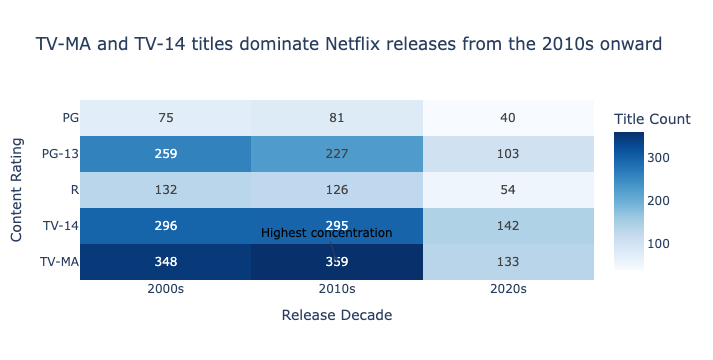

In [6]:
# Task 1 
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

ratings_keep = ['TV-14', 'TV-MA', 'PG-13', 'R', 'PG']
heatmap_df = df[df['rating'].isin(ratings_keep)]
heatmap_data = (
    heatmap_df
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
)
heatmap_pivot = heatmap_data.pivot(
    index='rating',
    columns='decade',
    values='count'
).fillna(0)

fig = px.imshow(
    heatmap_pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    labels=dict(color='Title Count'),
    title='TV-MA and TV-14 titles dominate Netflix releases from the 2010s onward'
)

fig.add_annotation(
    x='2010s',
    y='TV-MA',
    text='Highest concentration',
    showarrow=True,
    arrowhead=2,
    font=dict(color='black')
)

fig.update_layout(
    xaxis_title='Release Decade',
    yaxis_title='Content Rating'
)

fig.show()

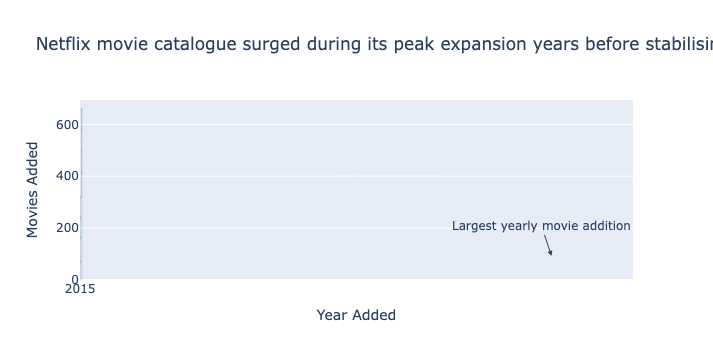

In [7]:
# Task 2 
movies = df[df['type'] == 'Movie']

movie_growth = (
    movies
    .groupby('added_year')
    .size()
    .reset_index(name='count')
)
movie_growth = movie_growth[
    (movie_growth['added_year'] >= 2015) &
    (movie_growth['added_year'] <= 2022)
].sort_values('added_year')
max_row = movie_growth.loc[movie_growth['count'].idxmax()]

fig = go.Figure(go.Waterfall(
    name='Movie Growth',
    orientation='v',
    measure=['relative'] * len(movie_growth) + ['total'],
    x=[str(year) for year in movie_growth['added_year']] + ['Total'],
    y=movie_growth['count'].tolist() + [0],
    
    increasing=dict(marker=dict(color='green')),
    decreasing=dict(marker=dict(color='red')),
    totals=dict(marker=dict(color='blue')),
    
    text=movie_growth['count'].tolist() + [movie_growth['count'].sum()],
    textposition='outside'
))

fig.add_annotation(
    x=str(max_row['added_year']),
    y=max_row['count'],
    text='Largest yearly movie addition',
    showarrow=True,
    arrowhead=2
)

fig.update_layout(
    title='Netflix movie catalogue surged during its peak expansion years before stabilising',
    xaxis_title='Year Added',
    yaxis_title='Movies Added',
    waterfallgap=0.3
)

fig.show()